In [2]:
"""
Extended Galerkin Neural Network (xGNN) for Least-Squares Regression.

Iteratively builds a solution by training small neural network basis functions
on residuals, optionally augmented with knowledge-based parametric functions,
then refitting all coefficients via least squares.

Based on the xGNN framework from Ainsworth & Dong (2024), simplified to
pure regression (no PDE).
"""

import copy
import logging
from dataclasses import dataclass, field
from typing import Callable, Optional

import torch
import torch.nn as nn

logger = logging.getLogger(__name__)


# ---------------------------------------------------------------------------
# Small feedforward network
# ---------------------------------------------------------------------------

class SmallNetwork(nn.Module):
    """Small feedforward network with tanh activation.

    The output layer has no bias. Its weights participate in gradient ascent
    training but are ultimately rescaled by the joint least-squares solve.
    """

    def __init__(self, input_dim: int, width: int, depth: int):
        super().__init__()
        layers: list[nn.Module] = []
        in_features = input_dim
        for _ in range(depth):
            layers.append(nn.Linear(in_features, width))
            layers.append(nn.Tanh())
            in_features = width
        self.hidden = nn.Sequential(*layers)
        self.output_layer = nn.Linear(width, 1, bias=False)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass. Returns shape (N,)."""
        h = self.hidden(x)
        return self.output_layer(h).squeeze(-1)


# ---------------------------------------------------------------------------
# Basis function wrapper
# ---------------------------------------------------------------------------

@dataclass
class BasisFunction:
    """Stores a trained SmallNetwork and frozen knowledge-based (callable, mu) pairs."""

    network: nn.Module
    phi_funcs: list[tuple[Callable, nn.Parameter]] = field(default_factory=list)

    def evaluate(self, X: torch.Tensor) -> torch.Tensor:
        """Evaluate the combined basis function at all data points. Returns (N,)."""
        with torch.no_grad():
            out = self.network(X)
            for phi_callable, mu in self.phi_funcs:
                out = out + phi_callable(X, mu)
        return out


# ---------------------------------------------------------------------------
# Training a single basis function
# ---------------------------------------------------------------------------

def _compute_objective(
    network: nn.Module,
    phi_funcs: list[tuple[Callable, nn.Parameter]],
    X: torch.Tensor,
    residuals: torch.Tensor,
) -> tuple[torch.Tensor, torch.Tensor]:
    """Compute the normalised correlation objective J = (r^T phi) / ||phi||."""
    phi_out = network(X)
    for phi_callable, mu in phi_funcs:
        phi_out = phi_out + phi_callable(X, mu)
    corr = (residuals * phi_out).sum()
    norm = phi_out.norm() + 1e-12
    objective = corr / norm
    return objective, phi_out


def train_basis_function(
    X: torch.Tensor,
    residuals: torch.Tensor,
    net_factory: Callable[[], nn.Module],
    phi_funcs: list[tuple[Callable, nn.Parameter]],
    lr: float,
    num_epochs: int,
    num_restarts: int = 3,
    device: torch.device | str = "cuda",
) -> tuple[nn.Module, list[tuple[Callable, nn.Parameter]], float]:
    """Train a combined basis function (NN + knowledge-based) to maximise
    the normalised correlation with the current residuals.

    Uses multiple random restarts, keeping the best result.

    Returns:
        (trained_network, trained_phi_funcs, best_objective_value)
    """
    best_obj = -float("inf")
    best_network = None
    best_phi_funcs = None

    # Save initial phi_funcs structure for restarts
    phi_callables = [fn for fn, _ in phi_funcs]
    mu_inits = [mu.data.clone() for _, mu in phi_funcs]

    for restart in range(num_restarts):
        net = net_factory().to(device)

        # Fresh mu parameters each restart
        current_phi_funcs: list[tuple[Callable, nn.Parameter]] = []
        for fn, mu_init in zip(phi_callables, mu_inits):
            mu = nn.Parameter(mu_init.clone().to(device))
            current_phi_funcs.append((fn, mu))

        # Collect trainable params
        params: list[torch.Tensor] = list(net.parameters())
        for _, mu in current_phi_funcs:
            params.append(mu)

        optimizer = torch.optim.Adam(params, lr=lr)

        final_obj = -float("inf")
        for epoch in range(num_epochs):
            optimizer.zero_grad()
            objective, _ = _compute_objective(net, current_phi_funcs, X, residuals)
            loss = -objective  # gradient ascent
            loss.backward()
            optimizer.step()
            final_obj = objective.item()

        if final_obj > best_obj:
            best_obj = final_obj
            best_network = copy.deepcopy(net)
            best_phi_funcs = [
                (fn, nn.Parameter(mu.data.clone()))
                for fn, mu in current_phi_funcs
            ]

    return best_network, best_phi_funcs, best_obj


# ---------------------------------------------------------------------------
# XGNNModel — stores the fitted model for prediction
# ---------------------------------------------------------------------------

@dataclass
class XGNNModel:
    """Fitted xGNN regression model."""

    basis_functions: list[BasisFunction]
    coefficients: torch.Tensor
    x_mean: torch.Tensor
    x_std: torch.Tensor
    y_mean: float
    y_std: float
    device: torch.device

    def predict(self, x_new: torch.Tensor) -> torch.Tensor:
        """Predict at new points. x_new shape: (N, d) or (N,) for 1-d."""
        x = torch.as_tensor(x_new, dtype=torch.float32, device=self.device)
        if x.ndim == 1:
            x = x.unsqueeze(-1)
        # normalise
        x_norm = (x - self.x_mean) / self.x_std

        # Evaluate each basis function
        n_basis = len(self.basis_functions)
        N = x_norm.shape[0]
        A = torch.zeros(N, n_basis, device=self.device)
        for j, bf in enumerate(self.basis_functions):
            A[:, j] = bf.evaluate(x_norm)

        y_norm = A @ self.coefficients
        # de-normalise
        return y_norm * self.y_std + self.y_mean


# ---------------------------------------------------------------------------
# Main algorithm
# ---------------------------------------------------------------------------

def xgnn_regression(
    X: torch.Tensor,
    y: torch.Tensor,
    tol: float = 1e-3,
    max_iter: int = 10,
    net_width: int = 32,
    net_depth: int = 2,
    phi_templates: Optional[list[tuple[Callable, float]]] = None,
    lr: float = 1e-3,
    num_epochs: int = 1000,
    num_restarts: int = 3,
    device: Optional[str] = None,
    net_factory: Optional[Callable[[int], nn.Module]] = None,
) -> XGNNModel:
    """Run the xGNN regression algorithm.

    Args:
        X: Input data, shape (N,) or (N, d).
        y: Target values, shape (N,).
        tol: Stopping tolerance on the objective / relative residual.
        max_iter: Maximum number of basis functions.
        net_width: Width of each sub-network (used when net_factory is None).
        net_depth: Number of hidden layers in each sub-network (used when net_factory is None).
        phi_templates: Optional list of (callable, initial_mu) for
            knowledge-based functions. Each callable has signature
            ``Phi(X_tensor, mu_param) -> (N,) tensor``.
        lr: Learning rate for Adam optimiser.
        num_epochs: Training epochs per basis function.
        num_restarts: Number of random restarts per basis function.
        device: Torch device string. Defaults to 'cuda'.
        net_factory: Optional callable ``(input_dim: int) -> nn.Module``.
            The returned module must map (N, input_dim) -> (N,).
            Defaults to SmallNetwork with net_width and net_depth.

    Returns:
        Fitted XGNNModel.
    """
    if device is None:
        device = "cuda"
    dev = torch.device(device)

    if net_factory is None:
        _w, _d = net_width, net_depth
        def net_factory(input_dim: int) -> nn.Module:
            return SmallNetwork(input_dim=input_dim, width=_w, depth=_d)

    # --- Prepare data -------------------------------------------------
    X = torch.as_tensor(X, dtype=torch.float32, device=dev)
    y = torch.as_tensor(y, dtype=torch.float32, device=dev)
    if X.ndim == 1:
        X = X.unsqueeze(-1)

    N, d = X.shape

    # Standardise X
    x_mean = X.mean(dim=0)
    x_std = X.std(dim=0)
    x_std[x_std == 0] = 1.0
    X_norm = (X - x_mean) / x_std

    # Standardise y
    y_mean = float(y.mean())
    y_std = float(y.std())
    if y_std == 0:
        y_std = 1.0
    y_norm = (y - y_mean) / y_std

    X_t = X_norm
    residuals = y_norm.clone()
    norm_y = torch.linalg.norm(y_norm)

    basis_functions: list[BasisFunction] = []
    basis_evals: list[torch.Tensor] = []
    coefficients = torch.empty(0, device=dev)

    logger.info("xGNN regression: N=%d, d=%d, tol=%.2e, max_iter=%d", N, d, tol, max_iter)

    for i in range(max_iter):
        # Create fresh knowledge-based params for this iteration
        phi_funcs: list[tuple[Callable, nn.Parameter]] = []
        if phi_templates is not None:
            for phi_callable, mu_init in phi_templates:
                mu = nn.Parameter(
                    torch.tensor(mu_init, dtype=torch.float32, device=dev)
                )
                phi_funcs.append((phi_callable, mu))

        # Step 1: Train basis function on residuals
        _factory = lambda: net_factory(d)
        trained_net, trained_phi, obj_value = train_basis_function(
            X_t, residuals, _factory, phi_funcs, lr, num_epochs,
            num_restarts=num_restarts, device=dev,
        )

        rel_residual = float(torch.linalg.norm(residuals) / (norm_y + 1e-30))
        logger.info(
            "  Iter %d: objective=%.6f, ||r||/||y||=%.6f",
            i + 1, obj_value, rel_residual,
        )

        # Step 3: Check stopping (on the objective)
        if abs(obj_value) < tol:
            logger.info("  Stopping: objective (%.2e) < tol (%.2e)", abs(obj_value), tol)
            break

        # Freeze parameters and store basis function
        for p in trained_net.parameters():
            p.requires_grad_(False)
        frozen_phi = []
        for fn, mu in trained_phi:
            mu.requires_grad_(False)
            frozen_phi.append((fn, mu))

        bf = BasisFunction(network=trained_net, phi_funcs=frozen_phi)
        basis_functions.append(bf)

        # Evaluate new basis at all data points
        new_eval = bf.evaluate(X_t)
        basis_evals.append(new_eval)

        # Step 2: Refit all coefficients jointly
        A = torch.column_stack(basis_evals)  # (N, i+1)
        coefficients = torch.linalg.lstsq(A, y_norm).solution

        # Update residuals
        residuals = y_norm - A @ coefficients

        # Secondary stopping: relative residual
        rel_res_after = float(torch.linalg.norm(residuals) / (norm_y + 1e-30))
        if rel_res_after < tol:
            logger.info(
                "  Stopping: relative residual (%.2e) < tol (%.2e)",
                rel_res_after, tol,
            )
            break

    return XGNNModel(
        basis_functions=basis_functions,
        coefficients=coefficients,
        x_mean=x_mean,
        x_std=x_std,
        y_mean=y_mean,
        y_std=y_std,
        device=dev,
    )


Test 1: f(x) = sin(3x) + 0.5*cos(7x) + noise
  Number of basis functions: 197
  Max error vs true: 0.000052


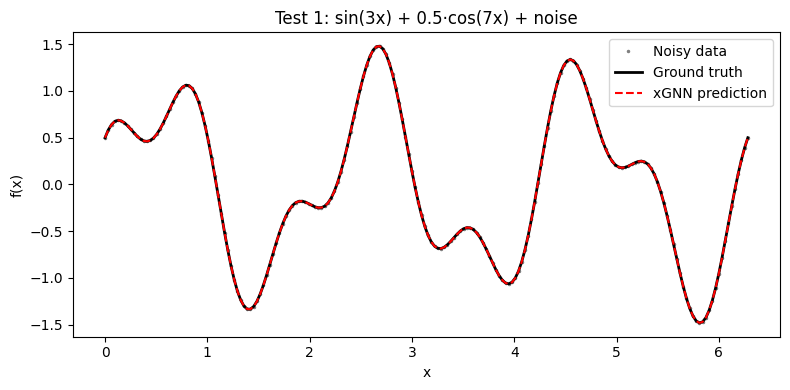


Test 2: f(x) = 2*sin(5x) + x^0.7 + 0.3*tanh(x-2) + noise
        Knowledge-based: sin(mu*x), x^mu
  Number of basis functions: 180
  Max error vs true: 0.000234


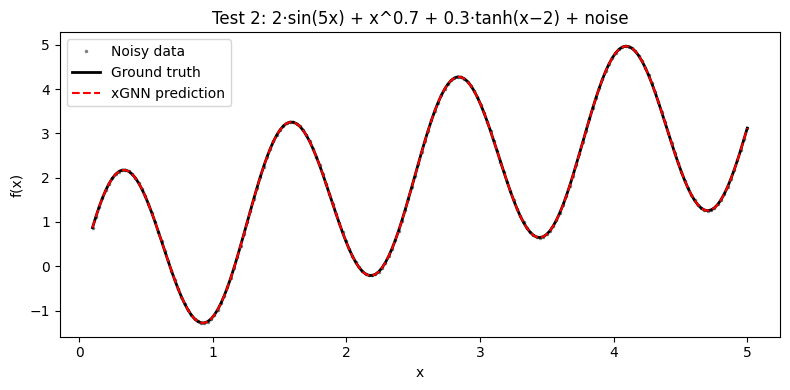


Test 3: Sharp-derivative function + noise
        f(x) = |x-2| + 2*step(x-4) + sqrt(|x-6|)
  Number of basis functions: 173
  Max error vs true: 0.000600


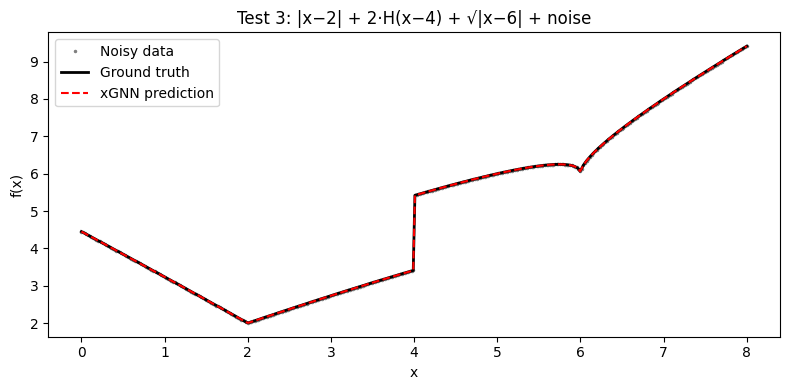

In [9]:
"""
Demo script for xGNN regression with three test problems.
All problems include additive Gaussian noise.

Test 1: f(x) = sin(3x) + 0.5*cos(7x) + noise, no knowledge-based functions.
Test 2: f(x) = 2*sin(5x) + x^0.7 + 0.3*tanh(x-2) + noise, with knowledge-based templates.
Test 3: f(x) = |x-pi|^0.5 * sign(x-pi) + sawtooth-like sharp features + noise.
"""

import logging
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

logging.basicConfig(level=logging.INFO, format="%(message)s")

# Force use of CUDA
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
NOISE_LEVEL = 0.
# Generator must also be on the same device as tensors
GEN = torch.Generator(device=DEVICE).manual_seed(42)

# ---- Test 1: Smooth function + noise, no knowledge-based functions -------

def test1():
    print("\n" + "=" * 60)
    print("Test 1: f(x) = sin(3x) + 0.5*cos(7x) + noise")
    print("=" * 60)

    x = torch.linspace(0, 2 * torch.pi, 200, device=DEVICE)
    y_true = torch.sin(3 * x) + 0.5 * torch.cos(7 * x)
    y = y_true + NOISE_LEVEL * torch.randn(x.shape[0], generator=GEN, device=DEVICE)

    model = xgnn_regression(
        X=x,
        y=y,
        tol=1e-5,
        max_iter=200,
        net_factory=lambda d: SmallNetwork(input_dim=d, width=256, depth=2).to(DEVICE),
        lr=1e-2,
        num_epochs=500,
        num_restarts=3,
        device=DEVICE
    )

    y_pred = model.predict(x).detach().cpu()
    print(f"  Number of basis functions: {len(model.basis_functions)}")
    print(f"  Max error vs true: {torch.max(torch.abs(y_true.cpu() - y_pred)):.6f}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x.cpu().numpy(), y.cpu().numpy(), ".", color="gray", markersize=3, label="Noisy data")
    ax.plot(x.cpu().numpy(), y_true.cpu().numpy(), "k-", lw=2, label="Ground truth")
    ax.plot(x.cpu().numpy(), y_pred.numpy(), "r--", lw=1.5, label="xGNN prediction")
    ax.set_title("Test 1: sin(3x) + 0.5·cos(7x) + noise")
    ax.legend()
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    fig.tight_layout()
    plt.show()


# ---- Test 2: Function with known structure + knowledge-based templates ---

def test2():
    print("\n" + "=" * 60)
    print("Test 2: f(x) = 2*sin(5x) + x^0.7 + 0.3*tanh(x-2) + noise")
    print("        Knowledge-based: sin(mu*x), x^mu")
    print("=" * 60)

    x = torch.linspace(0.1, 5, 200, device=DEVICE)
    y_true = 2 * torch.sin(5 * x) + x ** 0.7 + 0.3 * torch.tanh(x - 2)
    y = y_true + NOISE_LEVEL * torch.randn(x.shape[0], generator=GEN, device=DEVICE)

    def sin_template(X: torch.Tensor, mu: torch.Tensor) -> torch.Tensor:
        return torch.sin(mu * X.squeeze(-1))

    def power_template(X: torch.Tensor, mu: torch.Tensor) -> torch.Tensor:
        return X.squeeze(-1).abs().pow(mu)

    phi_templates = [
        (sin_template, 1.0),
        (power_template, 1.0),
    ]

    model = xgnn_regression(
        X=x,
        y=y,
        tol=1e-5,
        max_iter=200,
        net_factory=lambda d: SmallNetwork(input_dim=d, width=256, depth=2).to(DEVICE),
        phi_templates=phi_templates,
        lr=1e-2,
        num_epochs=500,
        num_restarts=3,
        device=DEVICE
    )

    y_pred = model.predict(x).detach().cpu()
    print(f"  Number of basis functions: {len(model.basis_functions)}")
    print(f"  Max error vs true: {torch.max(torch.abs(y_true.cpu() - y_pred)):.6f}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x.cpu().numpy(), y.cpu().numpy(), ".", color="gray", markersize=3, label="Noisy data")
    ax.plot(x.cpu().numpy(), y_true.cpu().numpy(), "k-", lw=2, label="Ground truth")
    ax.plot(x.cpu().numpy(), y_pred.numpy(), "r--", lw=1.5, label="xGNN prediction")
    ax.set_title("Test 2: 2·sin(5x) + x^0.7 + 0.3·tanh(x−2) + noise")
    ax.legend()
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    fig.tight_layout()
    plt.show()


# ---- Test 3: Sharp derivatives (kink + step + cusp) + noise -------------

def test3():
    print("\n" + "=" * 60)
    print("Test 3: Sharp-derivative function + noise")
    print("        f(x) = |x-2| + 2*step(x-4) + sqrt(|x-6|)")
    print("=" * 60)

    x = torch.linspace(0, 8, 400, device=DEVICE)
    y_true = torch.abs(x - 2) + 2.0 * (x >= 4).float() + torch.sqrt(torch.abs(x - 6))
    y = y_true + NOISE_LEVEL * torch.randn(x.shape[0], generator=GEN, device=DEVICE)

    model = xgnn_regression(
        X=x,
        y=y,
        tol=1e-5,
        max_iter=200,
        net_factory=lambda d: SmallNetwork(input_dim=d, width=256, depth=2).to(DEVICE),
        lr=1e-2,
        num_epochs=500,
        num_restarts=3,
        device=DEVICE
    )

    y_pred = model.predict(x).detach().cpu()
    print(f"  Number of basis functions: {len(model.basis_functions)}")
    print(f"  Max error vs true: {torch.max(torch.abs(y_true.cpu() - y_pred)):.6f}")

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.plot(x.cpu().numpy(), y.cpu().numpy(), ".", color="gray", markersize=3, label="Noisy data")
    ax.plot(x.cpu().numpy(), y_true.cpu().numpy(), "k-", lw=2, label="Ground truth")
    ax.plot(x.cpu().numpy(), y_pred.numpy(), "r--", lw=1.5, label="xGNN prediction")
    ax.set_title("Test 3: |x−2| + 2·H(x−4) + √|x−6| + noise")
    ax.legend()
    ax.set_xlabel("x")
    ax.set_ylabel("f(x)")
    fig.tight_layout()
    plt.show()

def custom_net(input_dim: int) -> nn.Module:
        return nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.GELU(),
            nn.Linear(64, 64),
            nn.GELU(),
            nn.Linear(64, 1),
            nn.Flatten(0),
        ).to(DEVICE)

if __name__ == "__main__":
    test1()
    test2()
    test3()